In [1]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [5]:
display(Image.open("../data/train/sar/GF2_Brasilia_-15.8652_-47.9351.tif"))

<PIL.TiffImagePlugin.TiffImageFile image mode=F size=512x512>

In [ ]:
cv2.imshow('x', x)

: 

In [4]:
import json

In [6]:
with open('track2/buildings_only_train.json') as f:
    data = json.load(f)

In [37]:
with open('example.json', 'w') as w:
    json.dump(data['annotations'][0], w, indent=4)

In [74]:
data['images'][1]

{'file_name': 'GF2_Brasilia_-15.8652_-47.9351.tif',
 'height': 512,
 'width': 512,
 'id': 1}

In [78]:
data['annotations'][3]

{'segmentation': [[331, 486, 193, 497, 185, 396, 323, 387, 331, 486]],
 'iscrowd': 0,
 'image_id': 0,
 'category_id': 1,
 'bbox': [185, 387, 146, 110],
 'area': 14118.0,
 'id': 3}

In [11]:
paths = []
for img_dict in data['images']:
    assert img_dict['height'] == img_dict['width'] == 512
    paths.append(img_dict['file_name'])


In [71]:
def write_paths(prefix):
    with open(f'{prefix}_train_paths.txt', 'w') as f:
        for path in paths:
            f.write(f'{path}\n')

In [72]:
write_paths('rgb')

In [19]:
y = [x.strip('\n') for x in open('rgb_train_paths.txt')]

In [82]:
class BasicDataSet():

    def __init__(self, json_data_file):
        # self.paths = [path.strip('\n') for path in open(paths_file)]
        self.metadata = json.load(open(json_data_file))
    
    def __len__(self):
        return len(self.metadata['images'])

    def __getitem__(self, index):
        # path = self.paths[index]
        img_metadata = self.metadata['images'][index]
        img = Image.open(f'rgb/{img_metadata['file_name']}')
        img_id = img_metadata['id']
        segmentation_labes = []
        for annotation in self.metadata['annotations']:
            if annotation['image_id'] == img_id:
                segmentation_labes.extend(annotation['segmentation'])

        return img.copy(), segmentation_labes

In [85]:
ds = BasicDataSet('track2/buildings_only_train.json')

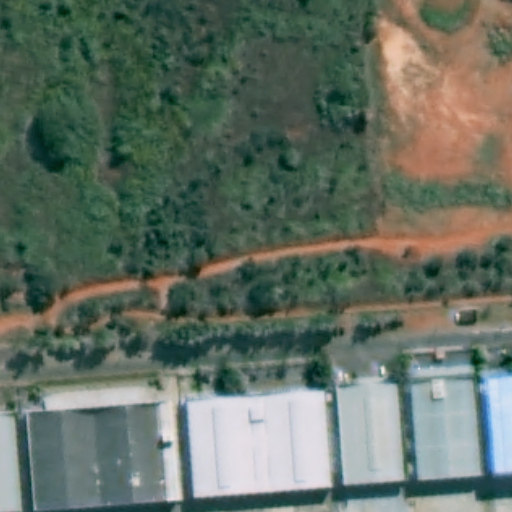

In [92]:
img_pil, ann = ds[0]
display(img_pil)

[166, 500, 33, 511, 25, 413, 44, 411, 158, 403, 166, 500]

In [ ]:
# ann = data['annotations'][0]

In [93]:
# img_pil = img
img =np.array(img_pil)
h, w = img.shape[:2]

In [95]:
mask = np.zeros((h, w), dtype=np.uint8)
for seg in ann:
    polygon = np.array(seg).reshape(-1, 2).astype(np.int32)
    cv2.fillPoly(mask, [polygon], color=1)

In [96]:
overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

In [97]:
alpha = 0.5
visualized = (overlay * alpha + img * (1 - alpha)).astype(np.uint8)

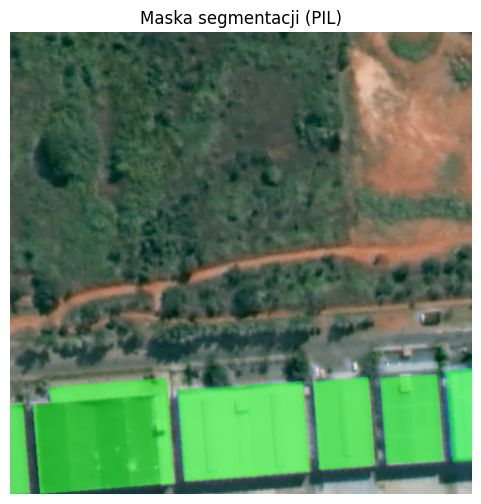

In [98]:
plt.figure(figsize=(6, 6))
plt.imshow(visualized)
plt.axis("off")
plt.title("Maska segmentacji (PIL)")
plt.show()

In [1]:
import torch

In [2]:
torch.cuda.is_available()

True